In [27]:
!pip install kaggle -q

In [28]:
# configuring the path of kaggle.jeson file
!mkdir -p  ~/.kaggle/
!cp kaggle.json  ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

**Importing the Face mask dataset**

In [29]:
# Api to featch the dataset from kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [30]:
# extracting the compressed dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [31]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


**Importing the dependencies**

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from sklearn.model_selection import train_test_split

In [33]:
with_mask_file= os.listdir('/content/data/with_mask')
print(with_mask_file[0:10])
print(with_mask_file[-10:])

['with_mask_1694.jpg', 'with_mask_1648.jpg', 'with_mask_143.jpg', 'with_mask_1806.jpg', 'with_mask_1874.jpg', 'with_mask_2483.jpg', 'with_mask_3598.jpg', 'with_mask_1454.jpg', 'with_mask_2625.jpg', 'with_mask_3650.jpg']
['with_mask_3397.jpg', 'with_mask_1079.jpg', 'with_mask_1360.jpg', 'with_mask_1506.jpg', 'with_mask_2622.jpg', 'with_mask_71.jpg', 'with_mask_1778.jpg', 'with_mask_2344.jpg', 'with_mask_3063.jpg', 'with_mask_739.jpg']


In [34]:
without_mask_file = os.listdir('/content/data/without_mask')
print(with_mask_file[0:10])
print(without_mask_file[-10:])

['with_mask_1694.jpg', 'with_mask_1648.jpg', 'with_mask_143.jpg', 'with_mask_1806.jpg', 'with_mask_1874.jpg', 'with_mask_2483.jpg', 'with_mask_3598.jpg', 'with_mask_1454.jpg', 'with_mask_2625.jpg', 'with_mask_3650.jpg']
['without_mask_2750.jpg', 'without_mask_3408.jpg', 'without_mask_83.jpg', 'without_mask_1935.jpg', 'without_mask_1479.jpg', 'without_mask_997.jpg', 'without_mask_1529.jpg', 'without_mask_3658.jpg', 'without_mask_143.jpg', 'without_mask_3641.jpg']


In [35]:
print('Number of mask images :' , len(with_mask_file))
print('Number of without mask images :' , len(without_mask_file))

Number of mask images : 3725
Number of without mask images : 3828


**Creating labels for the two class of images**

with mask --> 1

without --> 0

In [36]:
# create the labels

with_mask_labels =[1]*3725

without_mask_labels = [0]*3828

In [37]:
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [38]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [39]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the Images**

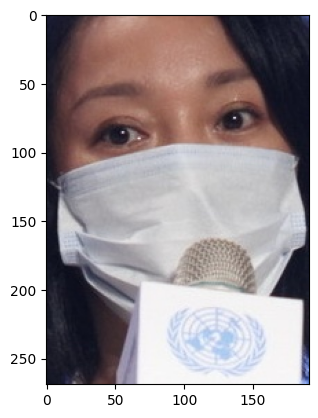

In [40]:
# displaying the with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1694.jpg')
imgplot = plt.imshow(img)
plt.show()

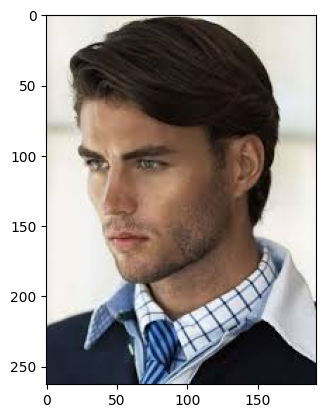

In [41]:
# displaying the with mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2750.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**

1. Resize the images

2. Convert the images to numpy arrays

In [42]:
from PIL import Image
# convert images to numpy arrays

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_file:
  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)


without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_file:
  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [43]:
type(data)

list

In [44]:
len(data)

7553

array([[[ 27,  28,  49],
        [ 25,  26,  47],
        [ 30,  31,  52],
        ...,
        [ 61,  69, 117],
        [ 69,  78, 135],
        [ 72,  81, 146]],

       [[ 26,  27,  48],
        [ 27,  28,  49],
        [ 29,  30,  51],
        ...,
        [ 55,  62, 100],
        [ 57,  65, 112],
        [ 65,  75, 128]],

       [[ 27,  28,  49],
        [ 27,  28,  49],
        [ 25,  26,  47],
        ...,
        [ 44,  49,  77],
        [ 47,  53,  87],
        [ 49,  55,  93]],

       ...,

       [[ 21,  23,  36],
        [ 21,  23,  36],
        [ 23,  25,  39],
        ...,
        [ 65,  72, 122],
        [ 54,  68, 129],
        [ 65,  86, 151]],

       [[ 19,  21,  34],
        [ 19,  21,  34],
        [ 22,  24,  37],
        ...,
        [116, 130, 188],
        [ 80, 100, 170],
        [ 68,  94, 167]],

       [[ 19,  21,  34],
        [ 17,  19,  32],
        [ 20,  22,  35],
        ...,
        [151, 172, 233],
        [139, 167, 237],
        [104, 137, 211]]], dtype=uint8)
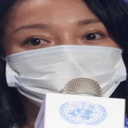

In [45]:
data[0]

In [46]:
type(data[0])

numpy.ndarray

In [47]:
data[0].shape

(128, 128, 3)

In [48]:
# converthing the image list and label list in numpy array

X = np.array(data)
Y = np.array(labels)

In [49]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


**Train Test Split**

In [50]:
X_train , X_test ,Y_train , Y_test = train_test_split( X , Y , test_size= 0.2 , random_state= 2 )

In [51]:
print(X.shape , X_train.shape , X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [52]:
# scalling the data

X_train_scaled = X_train/255
X_test_scaled = X_test/255

array([[[ 93,  95,  72],
        [ 98,  98,  77],
        [ 93,  93,  73],
        ...,
        [204, 211, 199],
        [209, 213, 200],
        [212, 216, 204]],

       [[ 90,  87,  58],
        [ 89,  86,  55],
        [ 84,  81,  49],
        ...,
        [207, 216, 210],
        [208, 217, 209],
        [210, 219, 210]],

       [[ 87,  84,  57],
        [ 84,  78,  49],
        [ 77,  73,  38],
        ...,
        [210, 220, 214],
        [208, 218, 212],
        [209, 219, 210]],

       ...,

       [[237, 189, 112],
        [222, 167,  92],
        [226, 172,  96],
        ...,
        [ 23,  22,  17],
        [ 43,  36,  32],
        [ 46,  38,  28]],

       [[238, 195, 118],
        [222, 166,  90],
        [229, 176,  98],
        ...,
        [ 34,  33,  28],
        [ 35,  29,  23],
        [ 38,  31,  25]],

       [[237, 195, 117],
        [217, 159,  84],
        [230, 176, 100],
        ...,
        [ 28,  27,  23],
        [ 40,  36,  31],
        [ 44,  39,  33]]], dtype=uint8)
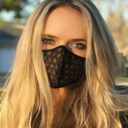

In [53]:
X_train[0]

In [54]:
X_train_scaled[0]

array([[[0.36470588, 0.37254902, 0.28235294],
        [0.38431373, 0.38431373, 0.30196078],
        [0.36470588, 0.36470588, 0.28627451],
        ...,
        [0.8       , 0.82745098, 0.78039216],
        [0.81960784, 0.83529412, 0.78431373],
        [0.83137255, 0.84705882, 0.8       ]],

       [[0.35294118, 0.34117647, 0.22745098],
        [0.34901961, 0.3372549 , 0.21568627],
        [0.32941176, 0.31764706, 0.19215686],
        ...,
        [0.81176471, 0.84705882, 0.82352941],
        [0.81568627, 0.85098039, 0.81960784],
        [0.82352941, 0.85882353, 0.82352941]],

       [[0.34117647, 0.32941176, 0.22352941],
        [0.32941176, 0.30588235, 0.19215686],
        [0.30196078, 0.28627451, 0.14901961],
        ...,
        [0.82352941, 0.8627451 , 0.83921569],
        [0.81568627, 0.85490196, 0.83137255],
        [0.81960784, 0.85882353, 0.82352941]],

       ...,

       [[0.92941176, 0.74117647, 0.43921569],
        [0.87058824, 0.65490196, 0.36078431],
        [0.88627451, 0

**Building a Convolutional Neural Network (CNN)**

In [55]:
import tensorflow as tf
from tensorflow import keras

In [67]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32 , kernel_size=(3,3) , activation='relu' , input_shape=(128,128,3)))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64 , kernel_size=(3,3) , activation='relu' , input_shape=(128,128,3)))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(128 , kernel_size=(3,3) , activation='relu' , input_shape=(128,128,3)))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128 , activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(128 , activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64 , activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes , activation='sigmoid'))

In [68]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [69]:
from IPython.core import history
# training the neural network
history = model.fit(X_train_scaled , Y_train , validation_split=0.2 , epochs=10)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - acc: 0.6605 - loss: 0.5941 - val_acc: 0.8511 - val_loss: 0.3709
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - acc: 0.8649 - loss: 0.3392 - val_acc: 0.8983 - val_loss: 0.2561
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - acc: 0.9007 - loss: 0.2546 - val_acc: 0.8743 - val_loss: 0.2828
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - acc: 0.9187 - loss: 0.2174 - val_acc: 0.9198 - val_loss: 0.2643
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - acc: 0.9352 - loss: 0.1795 - val_acc: 0.9115 - val_loss: 0.2242
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - acc: 0.9437 - loss: 0.1582 - val_acc: 0.9239 - val_loss: 0.2525
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - acc: 0.9549 - loss: 0.1299 - val_acc: 0.9479 - val_loss: 0.1579
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - acc: 0.9590 - loss: 0.1217 - val_acc: 0.9438 - val_loss: 0.1667
Epoch 9/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms

**Model Evaluation**

In [70]:
loss, accuracy = model.evaluate(X_test_scaled , Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9318 - loss: 0.1793
Test Accuracy = 0.9318332076072693


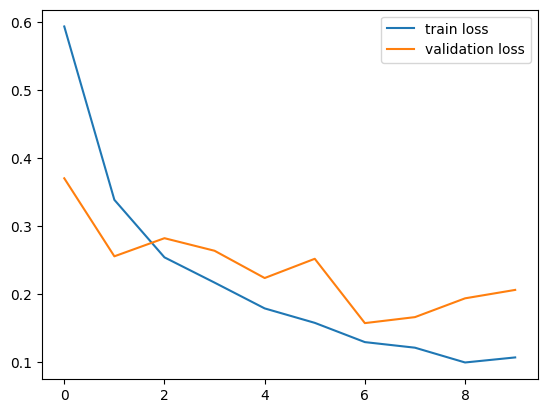

In [71]:
h = history

# plot the loss value

plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()



<function matplotlib.pyplot.show(close=None, block=None)>

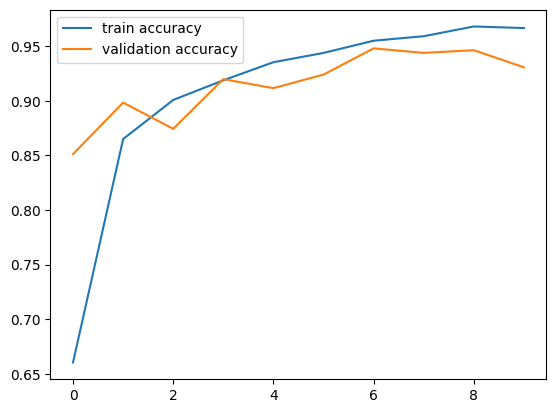

In [72]:
# plot the accuracy value

plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show

**Predictive System**

Enter the path of the image to be predicted/content/data/with_mask/with_mask_1694.jpg


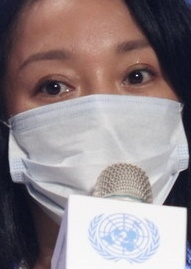

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[0.53168684 0.5681205 ]]
The person is wearing mask


In [73]:
input_image_path = input('Enter the path of the image to be predicted')

input_image = cv2.imread(input_image_path)
cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image , (128,128))

input_image_scaled = input_image_resize/255

input_image_reshaped = np.reshape(input_image_scaled , [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

predicted_class = np.argmax(input_prediction)

print(input_prediction)

if predicted_class == 1:
  print('The person is wearing mask')
else:
  print('The person is not wearing mask')

Enter the path of the image to be predicted/content/data/without_mask/without_mask_1056.jpg


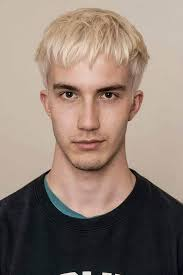

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[0.5690072  0.50073963]]
The person is not wearing mask


In [78]:
input_image_path = input('Enter the path of the image to be predicted')

input_image = cv2.imread(input_image_path)
cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image , (128,128))

input_image_scaled = input_image_resize/255

input_image_reshaped = np.reshape(input_image_scaled , [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

predicted_class = np.argmax(input_prediction)

print(input_prediction)


if predicted_class == 1:
  print('The person is wearing mask')
else:
  print('The person is not wearing mask')

In [79]:
from sklearn.metrics import classification_report

Y_pred_probabilities = model.predict(X_test_scaled)
Y_pred = np.argmax(Y_pred_probabilities, axis=1)

print(classification_report(Y_test, Y_pred))

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       768
           1       0.91      0.96      0.93       743

    accuracy                           0.93      1511
   macro avg       0.93      0.93      0.93      1511
weighted avg       0.93      0.93      0.93      1511

